# TabFM Benchmark — ETHUSDT Next-Close Regression

Benchmark TabFM against LSTM, XGBoost, Random Forest, and AdaBoost on the same chronological ETHUSDT dataset.

The prediction target is the **next hourly Close price**. The data is split chronologically into **70% train, 15% development, and 15% test**. The test set is kept untouched until final evaluation.


In [ ]:
# Install the dependencies used by this benchmark.
# TabFM 1.0.1 is used because the 1.0.0 PyTorch loader had a weight-loading issue.

%pip install -q "tabfm[pytorch]==1.0.1" xgboost scikit-learn pandas numpy matplotlib torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from tabfm import TabFMRegressor
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)


Device: cuda


In [ ]:
# Set this to the path of the ETHUSDT 1-hour CSV.
DATA_PATH = "sample_data/ETHUSDT_1h_6months.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Place the dataset beside this notebook "
        "or change DATA_PATH."
    )

df = pd.read_csv(DATA_PATH)

required_columns = ["Open Time", "Open", "High", "Low", "Close", "Volume"]
missing = [c for c in required_columns if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.copy()
df["Open Time"] = pd.to_datetime(df["Open Time"])
df = df.sort_values("Open Time").drop_duplicates("Open Time").reset_index(drop=True)

print("Rows:", len(df))
print("Range:", df["Open Time"].min(), "to", df["Open Time"].max())
df.head()


Rows: 4344
Range: 2026-02-25 14:00:00 to 2026-08-25 13:00:00


,Open Time,Open,High,Low,Close,Volume,Close Time,Quote Asset Volume,Number of Trades,Taker Buy Base Asset Volume,Taker Buy Quote Asset Volume,Ignore
0,2026-02-25 14:00:00,1964.57,2001.65,1962.14,1997.38,46629.0012,2026-02-25 14:59:59.999,9.231233e+07,656795,24822.2348,4.916200e+07,0
1,2026-02-25 15:00:00,1997.38,2028.70,1986.72,2013.73,54106.0004,2026-02-25 15:59:59.999,1.086752e+08,818545,25969.1556,5.216921e+07,0
2,2026-02-25 16:00:00,2013.69,2049.18,2013.36,2046.33,41815.8619,2026-02-25 16:59:59.999,8.495543e+07,586597,21227.3153,4.313233e+07,0
3,2026-02-25 17:00:00,2046.34,2086.17,2044.28,2073.90,52395.6223,2026-02-25 17:59:59.999,1.082330e+08,686165,25117.6370,5.188839e+07,0
4,2026-02-25 18:00:00,2073.90,2081.20,2056.93,2074.12,30666.6317,2026-02-25 18:59:59.999,6.347130e+07,457436,14683.0461,3.039653e+07,0


In [ ]:
# Feature engineering.

data = df.copy()

data["Target"] = data["Close"].shift(-1)

for lag in range(1, 5):
    data[f"Lag_{lag}"] = data["Close"].shift(lag)

for window in [3, 5, 7, 10]:
    data[f"SMA_{window}"] = data["Close"].rolling(window).mean()
    data[f"EMA_{window}"] = data["Close"].ewm(span=window, adjust=False).mean()

data["Range"] = data["High"] - data["Low"]
data["Body"] = data["Open"] - data["Close"]
data["Return"] = data["Close"].pct_change()

for window in [7, 10]:
    data[f"Volatility_{window}"] = data["Return"].rolling(window).std()
    data[f"Momentum_{window}"] = data["Return"].rolling(window).mean()

delta = data["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.rolling(10).mean()
avg_loss = loss.rolling(10).mean()
rs = avg_gain / avg_loss
data["RSI_10"] = 100 - (100 / (1 + rs))

data = data.dropna().reset_index(drop=True)

feature_columns = [
    "Open", "High", "Low", "Close", "Volume",
    "Lag_1", "Lag_2", "Lag_3", "Lag_4",
    "SMA_3", "SMA_5", "SMA_7", "SMA_10",
    "EMA_3", "EMA_5", "EMA_7", "EMA_10",
    "Range", "Body", "Return",
    "Volatility_7", "Volatility_10",
    "Momentum_7", "Momentum_10", "RSI_10"
]

X = data[feature_columns].copy()
y = data["Target"].copy()

print("Usable rows:", len(data))
print("Features:", len(feature_columns))


Usable rows: 4333
Features: 25


In [ ]:
# One chronological split used by every model.

n = len(data)
train_end = int(n * 0.70)
dev_end = int(n * 0.85)

split_labels = np.full(n, "test", dtype=object)
split_labels[:train_end] = "train"
split_labels[train_end:dev_end] = "dev"

data["Split"] = split_labels

print(f"Train: {train_end} rows ({train_end / n:.2%})")
print(f"Dev:   {dev_end - train_end} rows ({(dev_end - train_end) / n:.2%})")
print(f"Test:  {n - dev_end} rows ({(n - dev_end) / n:.2%})")

print("\nDate boundaries:")
print("Train:", data.loc[0, "Open Time"], "->", data.loc[train_end - 1, "Open Time"])
print("Dev:  ", data.loc[train_end, "Open Time"], "->", data.loc[dev_end - 1, "Open Time"])
print("Test: ", data.loc[dev_end, "Open Time"], "->", data.loc[n - 1, "Open Time"])


Train: 3033 rows (70.00%)
Dev:   650 rows (15.00%)
Test:  650 rows (15.00%)

Date boundaries:
Train: 2026-02-26 00:00:00 -> 2026-07-02 08:00:00
Dev:   2026-07-02 09:00:00 -> 2026-07-29 10:00:00
Test:  2026-07-29 11:00:00 -> 2026-08-25 12:00:00


In [ ]:
X_train = X.iloc[:train_end].copy()
X_dev = X.iloc[train_end:dev_end].copy()
X_test = X.iloc[dev_end:].copy()

y_train = y.iloc[:train_end].copy()
y_dev = y.iloc[train_end:dev_end].copy()
y_test = y.iloc[dev_end:].copy()

print(X_train.shape, X_dev.shape, X_test.shape)


(3033, 25) (650, 25) (650, 25)


## XGBoost

In [ ]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)

xgb_dev_pred = xgb_model.predict(X_dev)
xgb_test_pred = xgb_model.predict(X_test)


## Random Forest

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=SEED,
    n_jobs=-1,
    max_features=1.0,
)

rf_model.fit(X_train, y_train)

rf_dev_pred = rf_model.predict(X_dev)
rf_test_pred = rf_model.predict(X_test)


## AdaBoost

In [ ]:
ada_base = DecisionTreeRegressor(max_depth=4, random_state=SEED)

ada_model = AdaBoostRegressor(
    estimator=ada_base,
    n_estimators=200,
    learning_rate=0.05,
    random_state=SEED,
)

ada_model.fit(X_train, y_train)

ada_dev_pred = ada_model.predict(X_dev)
ada_test_pred = ada_model.predict(X_test)


## TabFM

In [ ]:
tabfm_device = "cuda" if torch.cuda.is_available() else "cpu"

print("TabFM device:", tabfm_device)
if tabfm_device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

tabfm_base = tabfm_v1_0_0.load(
    model_type="regression",
    device=tabfm_device,
)

TABFM_N_ESTIMATORS = 32
TABFM_MAX_NUM_FEATURES = 25
TABFM_MAX_NUM_ROWS = 100

tabfm_model = TabFMRegressor(
    model=tabfm_base,
    n_estimators=TABFM_N_ESTIMATORS,
    max_num_features=TABFM_MAX_NUM_FEATURES,
    max_num_rows=TABFM_MAX_NUM_ROWS,
)

y_train_tabfm = np.asarray(y_train, dtype=np.float32)

# Fit only prepares the in-context training data.
fit_start = time.time()

tabfm_model.fit(X_train, y_train_tabfm)

fit_time = time.time() - fit_start
print(f"TabFM fit time: {fit_time:.2f} seconds")

# Prediction is the expensive part of TabFM.
dev_start = time.time()
tabfm_dev_pred = tabfm_model.predict(X_dev)
dev_time = time.time() - dev_start

print(f"TabFM dev prediction time: {dev_time:.2f} seconds")

test_start = time.time()
tabfm_test_pred = tabfm_model.predict(X_test)
test_time = time.time() - test_start

print(f"TabFM test prediction time: {test_time:.2f} seconds")


TabFM device: cuda
GPU: Tesla T4
TabFM fit time: 0.17 seconds
TabFM dev prediction time: 50.23 seconds
TabFM test prediction time: 51.27 seconds


## LSTM

In [ ]:
sequence_columns = ["Open", "High", "Low", "Close", "Volume"]
sequence_length = 24

sequence_scaler = MinMaxScaler()
sequence_scaler.fit(data.loc[:train_end - 1, sequence_columns])

sequence_scaled = sequence_scaler.transform(data[sequence_columns])

# Close is column 3 in sequence_columns, so use its scaled value as y.
y_lstm_scaled = sequence_scaled[:, 3]

def make_sequence_dataset(scaled_values, scaled_target, target_start, target_end, seq_len):
    X_out, y_out = [], []

    for target_idx in range(target_start, target_end):
        X_out.append(scaled_values[target_idx - seq_len:target_idx])
        y_out.append(scaled_target[target_idx])

    return np.asarray(X_out, dtype=np.float32), np.asarray(y_out, dtype=np.float32)

X_lstm_train, y_lstm_train = make_sequence_dataset(
    sequence_scaled, y_lstm_scaled, sequence_length, train_end, sequence_length
)

X_lstm_dev, y_lstm_dev = make_sequence_dataset(
    sequence_scaled, y_lstm_scaled, train_end, dev_end, sequence_length
)

X_lstm_test, y_lstm_test = make_sequence_dataset(
    sequence_scaled, y_lstm_scaled, dev_end, n, sequence_length
)

print("LSTM:", X_lstm_train.shape, X_lstm_dev.shape, X_lstm_test.shape)


LSTM: (3009, 24, 5) (650, 24, 5) (650, 24, 5)


In [ ]:
class CryptoLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size = x.size(0)

        h0 = torch.zeros(
            self.num_layers, batch_size, self.hidden_size, device=x.device
        )
        c0 = torch.zeros(
            self.num_layers, batch_size, self.hidden_size, device=x.device
        )

        output, _ = self.lstm(x, (h0, c0))
        return self.fc(output[:, -1, :]).squeeze(-1)


train_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_lstm_train),
        torch.tensor(y_lstm_train),
    ),
    batch_size=64,
    shuffle=True,
)

dev_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_lstm_dev),
        torch.tensor(y_lstm_dev),
    ),
    batch_size=64,
    shuffle=False,
)

test_loader = DataLoader(
    TensorDataset(
        torch.tensor(X_lstm_test),
        torch.tensor(y_lstm_test),
    ),
    batch_size=64,
    shuffle=False,
)

lstm_model = CryptoLSTM().to(DEVICE)
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
criterion = nn.MSELoss()

num_epochs = 50
patience = 8

best_dev_loss = float("inf")
best_state = None
patience_counter = 0

train_losses = []
dev_losses = []

for epoch in range(num_epochs):
    lstm_model.train()
    train_batch_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        pred = lstm_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        train_batch_losses.append(loss.item())

    train_loss = float(np.mean(train_batch_losses))
    train_losses.append(train_loss)

    lstm_model.eval()
    dev_batch_losses = []

    with torch.no_grad():
        for xb, yb in dev_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            pred = lstm_model(xb)
            dev_batch_losses.append(criterion(pred, yb).item())

    dev_loss = float(np.mean(dev_batch_losses))
    dev_losses.append(dev_loss)

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train: {train_loss:.6f} | Dev: {dev_loss:.6f}"
    )

    if dev_loss < best_dev_loss:
        best_dev_loss = dev_loss
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in lstm_model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping.")
            break

lstm_model.load_state_dict(best_state)
lstm_model.to(DEVICE)


Epoch 01/50 | Train: 0.067249 | Dev: 0.000580
Epoch 02/50 | Train: 0.001659 | Dev: 0.000554
Epoch 03/50 | Train: 0.001125 | Dev: 0.000669
Epoch 04/50 | Train: 0.001156 | Dev: 0.000712
Epoch 05/50 | Train: 0.001079 | Dev: 0.000629
Epoch 06/50 | Train: 0.001068 | Dev: 0.000485
Epoch 07/50 | Train: 0.000991 | Dev: 0.000477
Epoch 08/50 | Train: 0.000920 | Dev: 0.000446
Epoch 09/50 | Train: 0.000968 | Dev: 0.000841
Epoch 10/50 | Train: 0.000975 | Dev: 0.000730
Epoch 11/50 | Train: 0.001070 | Dev: 0.001051
Epoch 12/50 | Train: 0.000947 | Dev: 0.000370
Epoch 13/50 | Train: 0.000825 | Dev: 0.000331
Epoch 14/50 | Train: 0.000913 | Dev: 0.000368
Epoch 15/50 | Train: 0.000824 | Dev: 0.000366
Epoch 16/50 | Train: 0.000743 | Dev: 0.000324
Epoch 17/50 | Train: 0.000734 | Dev: 0.000381
Epoch 18/50 | Train: 0.000729 | Dev: 0.000432
Epoch 19/50 | Train: 0.000712 | Dev: 0.000262
Epoch 20/50 | Train: 0.000736 | Dev: 0.000444
Epoch 21/50 | Train: 0.000754 | Dev: 0.000418
Epoch 22/50 | Train: 0.000704 | De

CryptoLSTM(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [ ]:
def predict_lstm(loader):
    lstm_model.eval()
    preds = []

    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(DEVICE)
            preds.append(lstm_model(xb).cpu().numpy())

    return np.concatenate(preds)

# Model outputs are scaled Close values. Convert them back to actual Close prices.
def inverse_close_scale(values, scaler):
    dummy = np.zeros((len(values), len(sequence_columns)), dtype=np.float64)
    dummy[:, 3] = values
    return scaler.inverse_transform(dummy)[:, 3]

lstm_dev_pred_scaled = predict_lstm(dev_loader)
lstm_test_pred_scaled = predict_lstm(test_loader)

lstm_dev_pred = inverse_close_scale(lstm_dev_pred_scaled, sequence_scaler)
lstm_test_pred = inverse_close_scale(lstm_test_pred_scaled, sequence_scaler)


## Evaluation

In [ ]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
    }

predictions = {
    "XGBoost": (xgb_dev_pred, xgb_test_pred),
    "Random Forest": (rf_dev_pred, rf_test_pred),
    "AdaBoost": (ada_dev_pred, ada_test_pred),
    "TabFM": (tabfm_dev_pred, tabfm_test_pred),
    "LSTM": (lstm_dev_pred, lstm_test_pred),
}

dev_results = []
test_results = []

for model_name, (dev_pred, test_pred) in predictions.items():
    dev_metric = regression_metrics(y_dev, dev_pred)
    test_metric = regression_metrics(y_test, test_pred)

    dev_results.append({"Model": model_name, **dev_metric})
    test_results.append({"Model": model_name, **test_metric})

dev_results = pd.DataFrame(dev_results).sort_values("RMSE")
test_results = pd.DataFrame(test_results).sort_values("RMSE")

print("Development results")
display(dev_results)

print("Test results")
display(test_results)


Development results


,Model,MAE,RMSE,R2
3,TabFM,6.099950,8.906968,0.983155
0,XGBoost,9.698129,12.781011,0.965315
2,AdaBoost,11.856182,15.220177,0.950813
4,LSTM,10.423873,15.293148,0.950340
1,Random Forest,11.948448,15.922947,0.946165


Test results


,Model,MAE,RMSE,R2
3,TabFM,7.531185,12.951384,0.996403
4,LSTM,11.120762,20.455068,0.991026
0,XGBoost,15.727289,23.502862,0.988153
1,Random Forest,21.166150,26.934660,0.984441
2,AdaBoost,20.720463,31.012300,0.979373


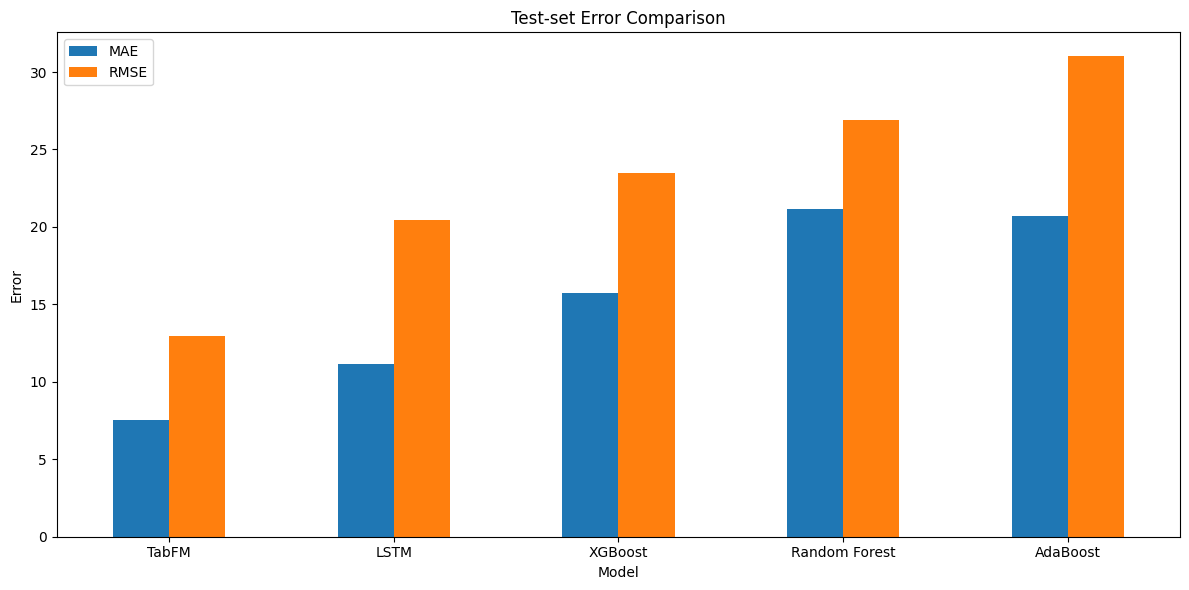

In [ ]:
# Final test-set comparison.

ax = test_results.set_index("Model")[["MAE", "RMSE"]].plot(
    kind="bar", figsize=(12, 6)
)
ax.set_ylabel("Error")
ax.set_title("Test-set Error Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


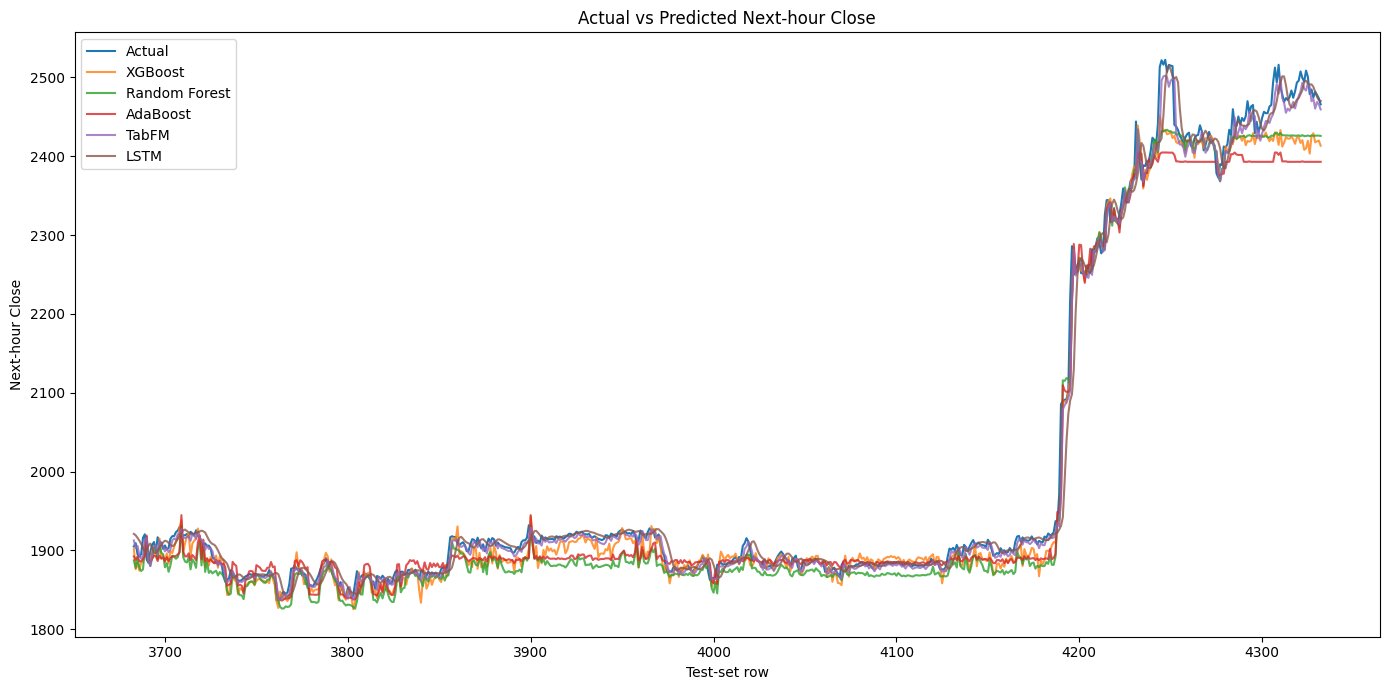

In [ ]:
# Actual vs predicted on the untouched test set.

test_index = data.index[dev_end:]

plt.figure(figsize=(14, 7))
plt.plot(test_index, y_test.to_numpy(), label="Actual")

for model_name, (_, test_pred) in predictions.items():
    plt.plot(test_index, test_pred, label=model_name, alpha=0.8)

plt.xlabel("Test-set row")
plt.ylabel("Next-hour Close")
plt.title("Actual vs Predicted Next-hour Close")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Save predictions and metrics for the repository.

prediction_frame = pd.DataFrame({
    "Open Time": data.loc[dev_end:, "Open Time"].to_numpy(),
    "Actual": y_test.to_numpy(),
    "XGBoost": xgb_test_pred,
    "Random Forest": rf_test_pred,
    "AdaBoost": ada_test_pred,
    "TabFM": tabfm_test_pred,
    "LSTM": lstm_test_pred,
})

prediction_frame.to_csv("test_predictions.csv", index=False)
dev_results.to_csv("dev_results.csv", index=False)
test_results.to_csv("test_results.csv", index=False)

print("Saved:")
print("  test_predictions.csv")
print("  dev_results.csv")
print("  test_results.csv")


Saved:
  test_predictions.csv
  dev_results.csv
  test_results.csv


### Notes for the benchmark

- The split is chronological: 70% train, 15% development, 15% test.
- The test set is not used for model fitting or LSTM early stopping.
- TabFM is a pretrained model; its `fit()` prepares the tabular context rather than updating the pretrained weights.
- TabFM uses `n_estimators=32` for a practical ensemble size on Colab T4; `max_num_rows=100` remains the context-row limit.
- The current project is a **regression benchmark for next-hour Close**, not a probability-classification benchmark.
